# Zadania z przetwarzania tekstów z zajęć projektowych

### Google Colab Setup

**Important Notes:**
- This notebook performs text analysis (WordCloud, n-grams, NER) - CPU-based operations
- GPU (T4) won't be utilized for these tasks
- NER processing with Stanza may take several minutes

**Required files to upload:**
- `HealthStory_cleaned.csv` → upload to `/content/sample_data/`
- `HealthStory_combined.csv` → upload to `/content/sample_data/` (if available)

**Note:** If you don't have the CSV files, run the data preparation step first using the original JSON file.

## Package Installation

In [1]:
# Install required packages for Google Colab
%pip install -q wordcloud pandas matplotlib nltk stanza spacy textblob

# Download required NLTK data
import nltk
nltk.download('stopwords')
nltk.download('punkt')

# Download spaCy model
!python -m spacy download en_core_web_sm

print("✓ All packages installed!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 81.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✓ All packages installed!


## WordCloud

✓ Wczytano plik z sample_data/HealthStory_cleaned.csv


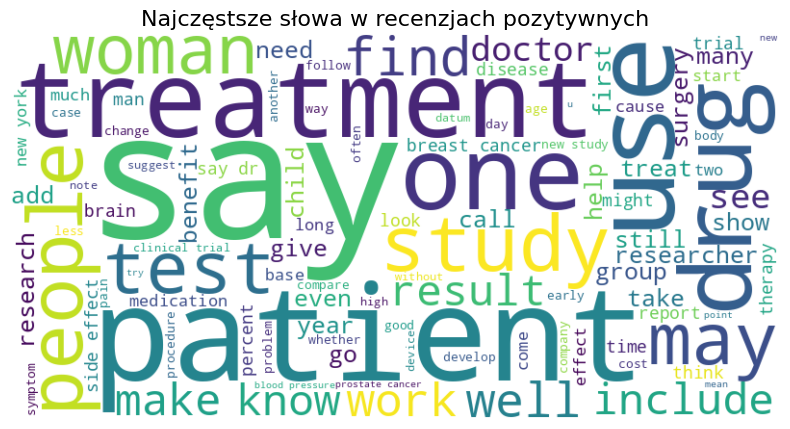

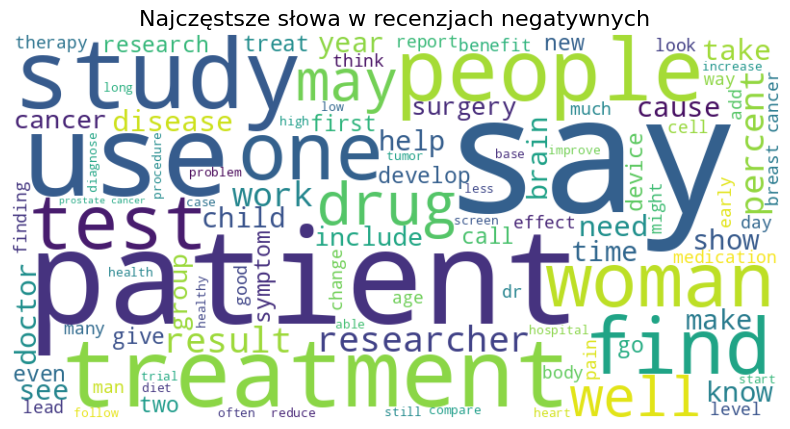

In [2]:
# --- 1a. WordCloud dla wizualizacji najczęstszych słów ---
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import pandas as pd
import os

# Google Colab: pliki w sample_data/
DATA_PATH = 'sample_data/HealthStory_cleaned.csv'

if os.path.exists(DATA_PATH):
    df_clean = pd.read_csv(DATA_PATH)
    print(f"✓ Wczytano plik z {DATA_PATH}")
elif os.path.exists('HealthStory_cleaned.csv'):
    df_clean = pd.read_csv('HealthStory_cleaned.csv')
    print("✓ Wczytano plik lokalny")
else:
    raise FileNotFoundError("Wgraj plik HealthStory_cleaned.csv do sample_data/")

# Pozytywne recenzje
positive_text = " ".join(df_clean[df_clean['rating'] >= 3]['text'].astype(str))
# Negatywne recenzje
negative_text = " ".join(df_clean[df_clean['rating'] < 3]['text'].astype(str))

# Funkcja do generowania i wyświetlania wordclouda
def plot_wordcloud(text, title):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100,
        colormap='viridis'
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

plot_wordcloud(positive_text, "Najczęstsze słowa w recenzjach pozytywnych")
plot_wordcloud(negative_text, "Najczęstsze słowa w recenzjach negatywnych")


## N-gramy

In [3]:
from nltk.util import ngrams
from collections import Counter

def top_ngrams(p_tokens, n=2, k=10):
  ng = ngrams(p_tokens, n)
  c = Counter(ng)
  return c.most_common(k)

In [4]:
texts  = df_clean['text'].astype(str)
def tokenize(p_texts):
    r_tokens = []
    for text in texts:
        r_tokens.extend(text.split())
    return r_tokens

tokens = tokenize(texts)

In [5]:
print("\nTop 10 bigramów:")
for pair, c in top_ngrams(tokens, n=2, k=10):
  print(f"{pair} -> {c}")


Top 10 bigramów:
('breast', 'cancer') -> 763
('say', 'dr') -> 718
('side', 'effect') -> 669
('new', 'york') -> 584
('new', 'study') -> 583
('prostate', 'cancer') -> 478
('clinical', 'trial') -> 460
('blood', 'pressure') -> 434
('heart', 'attack') -> 430
('study', 'publish') -> 387


In [6]:
print("\nTop 10 trigramów:")
for pair, c in top_ngrams(tokens, 3, 10):
  print(f"{pair} -> {c}")


Top 10 trigramów:
('food', 'drug', 'administration') -> 256
('new', 'england', 'journal') -> 153
('en', 'espa', 'ol') -> 152
('new', 'york', 'city') -> 151
('england', 'journal', 'medicine') -> 150
('new', 'york', 'times') -> 150
('high', 'blood', 'pressure') -> 142
('continue', 'read', 'main') -> 140
('read', 'main', 'story') -> 140
('heart', 'attack', 'stroke') -> 132


## Najbardziej reprezentatywne słowa - `log_odds`

In [7]:
import math

positive_texts = df_clean[df_clean['rating'] >= 3]['text'].astype(str)
negative_texts = df_clean[df_clean['rating'] < 3]['text'].astype(str)

pos_tokens = tokenize(positive_texts)
neg_tokens = tokenize(negative_texts)

pos_freq = Counter(pos_tokens)
neg_freq = Counter(neg_tokens)

In [8]:
def relative_freq(counter):
  total = sum(counter.values())
  return { w : (c/total if total else 0.0) for w, c in counter.items() }

rf_pos = relative_freq(pos_freq)
rf_neg = relative_freq(neg_freq)

In [9]:
def log_odds(c_pos, t_pos, c_neg, t_neg, alpha=1.0):
  return math.log((c_pos + alpha) / (t_pos - c_pos + alpha)) - math.log((c_neg + alpha) / (t_neg - c_neg + alpha))

In [10]:
tpos = sum(pos_freq.values())
tneg = sum(neg_freq.values())
vocab = set(pos_freq) | set(neg_freq)

scores = []
for w in vocab:
  cp, cn = pos_freq.get(w, 0), neg_freq.get(w, 0)
  lo = log_odds(cp, tpos, cn, tneg, alpha=1.0)
  scores.append((w, cp, cn, rf_pos.get(w, 0.0), rf_neg.get(w, 0.0), lo))

scores_sorted_pos = sorted(scores, key=lambda x: x[5], reverse=True)[:10]
scores_sorted_neg = sorted(scores, key=lambda x: x[5])[:10]

In [11]:
def print_stats(scores, title):
  print(f'Najbardziej reprezentatywne słowa - {title} (log_odds):')
  for w, cp, cn, rf_pos, rf_neg, lo in scores:
    print(f'{w:<15} pos= {cp}, neg= {cn}, rf_pos= {rf_pos:.3f}, rf_neg= {rf_neg:.3f}, log_odds= {lo:.3f}')

In [12]:
print_stats(scores_sorted_pos, 'pozytywne')
print()
print_stats(scores_sorted_neg, 'negatywne')

Najbardziej reprezentatywne słowa - pozytywne (log_odds):
outbreaks       pos= 1, neg= 1, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
hopingto        pos= 1, neg= 1, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
gambia          pos= 17, neg= 17, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
cram            pos= 3, neg= 3, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
dacarbazine     pos= 13, neg= 13, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
nosebleed       pos= 1, neg= 1, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
girl            pos= 72, neg= 72, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
printer         pos= 3, neg= 3, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
methane         pos= 1, neg= 1, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
pain            pos= 1064, neg= 1064, rf_pos= 0.002, rf_neg= 0.002, log_odds= 0.000

Najbardziej reprezentatywne słowa - negatywne (log_odds):
outbreaks       pos= 1, neg= 1, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
hopingto     

## Podobieństwo tekstów (dla 10 tekstów)

In [13]:
from sklearn. feature_extraction.text import TfidfVectorizer
import numpy as np

corpus = df_clean['text'].astype(str).head(10)
vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1,2), min_df=1)
X = vectorizer.fit_transform(corpus)

vocab = np.array(vectorizer.get_feature_names_out())
print("Kształt macierzy TF-IDF:", X.shape)

global_weights = np.asarray(X.sum(axis=0)).ravel()
top_idx = np.argsort(-global_weights) [:20]
df_top = pd.DataFrame({
    "term": vocab[top_idx],
    "sum_tfidf": global_weights[top_idx]
})

df_top

Kształt macierzy TF-IDF: (10, 4281)


,term,sum_tfidf
0,say,0.842363
1,cancer,0.629223
2,alzheimer,0.581365
3,patient,0.528080
4,study,0.497885
5,woman,0.470329
6,peanut,0.469894
7,disease,0.464233
8,people,0.404318
9,treatment,0.389900


### Podobieństwo cosinusowe

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(X)
pd.DataFrame(cos_sim, index=[f"Dokument {i+1}" for i in range(len(corpus))],
             columns=[f"Dokument {i+1}" for i in range(len(corpus))])

,Dokument 1,Dokument 2,Dokument 3,Dokument 4,Dokument 5,Dokument 6,Dokument 7,Dokument 8,Dokument 9,Dokument 10
Dokument 1,1.000000,0.023661,0.042513,0.030517,0.046127,0.075455,0.034672,0.046593,0.197366,0.048008
Dokument 2,0.023661,1.000000,0.045444,0.079029,0.051459,0.027086,0.022186,0.030077,0.022324,0.041105
Dokument 3,0.042513,0.045444,1.000000,0.021114,0.066000,0.051187,0.043820,0.043776,0.022711,0.071504
Dokument 4,0.030517,0.079029,0.021114,1.000000,0.038745,0.040884,0.035833,0.056907,0.039651,0.047558
Dokument 5,0.046127,0.051459,0.066000,0.038745,1.000000,0.055874,0.064852,0.141943,0.048138,0.083959
Dokument 6,0.075455,0.027086,0.051187,0.040884,0.055874,1.000000,0.082659,0.061515,0.062854,0.078336
Dokument 7,0.034672,0.022186,0.043820,0.035833,0.064852,0.082659,1.000000,0.067988,0.037820,0.072196
Dokument 8,0.046593,0.030077,0.043776,0.056907,0.141943,0.061515,0.067988,1.000000,0.038209,0.068429
Dokument 9,0.197366,0.022324,0.022711,0.039651,0.048138,0.062854,0.037820,0.038209,1.000000,0.048858
Dokument 10,0.048008,0.041105,0.071504,0.047558,0.083959,0.078336,0.072196,0.068429,0.048858,1.000000


### Miara Jaccarda

In [15]:
corpus = list(corpus)
token_sets = [set(doc.split()) for doc in corpus]

def jaccard(a, b):
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union else 0.0

J = np.zeros((len(corpus), len(corpus)))
for i in range(len(corpus)):
    for j in range(len(corpus)):
        J[i,j] = jaccard(token_sets[i], token_sets[j])

pd.DataFrame(J, index=[f"Dokument {i+1}" for i in range(len(corpus))],
columns=[f"Dokument {i+1}" for i in range(len(corpus))])

,Dokument 1,Dokument 2,Dokument 3,Dokument 4,Dokument 5,Dokument 6,Dokument 7,Dokument 8,Dokument 9,Dokument 10
Dokument 1,1.000000,0.069686,0.097561,0.105802,0.127820,0.115578,0.084112,0.110818,0.128920,0.115530
Dokument 2,0.069686,1.000000,0.051020,0.132780,0.061170,0.050802,0.045570,0.075581,0.062257,0.056974
Dokument 3,0.097561,0.051020,1.000000,0.055016,0.116049,0.082524,0.081206,0.110236,0.079470,0.112994
Dokument 4,0.105802,0.132780,0.055016,1.000000,0.089005,0.078947,0.066998,0.105714,0.094340,0.083984
Dokument 5,0.127820,0.061170,0.116049,0.089005,1.000000,0.112033,0.144033,0.132450,0.124324,0.162116
Dokument 6,0.115578,0.050802,0.082524,0.078947,0.112033,1.000000,0.117886,0.116740,0.111111,0.134454
Dokument 7,0.084112,0.045570,0.081206,0.066998,0.144033,0.117886,1.000000,0.111814,0.094148,0.130081
Dokument 8,0.110818,0.075581,0.110236,0.105714,0.132450,0.116740,0.111814,1.000000,0.096317,0.124138
Dokument 9,0.128920,0.062257,0.079470,0.094340,0.124324,0.111111,0.094148,0.096317,1.000000,0.096838
Dokument 10,0.115530,0.056974,0.112994,0.083984,0.162116,0.134454,0.130081,0.124138,0.096838,1.000000


## NER

In [16]:
import spacy
import stanza

nlp_spacy = spacy.load('en_core_web_sm')

stanza.download("en")
nlp_stanza = stanza.Pipeline(lang="en", preprocessors="tokenize,pos,ner")

INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: en (English) ...


INFO:stanza:Downloaded file to /root/stanza_resources/en/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: en (English):
| Processor    | Package                   |
--------------------------------------------
| tokenize     | combined                  |
| mwt          | combined                  |
| pos          | combined_charlm           |
| lemma        | combined_nocharlm         |
| constituency | ptb3-revised_charlm       |
| depparse     | combined_charlm           |
| sentiment    | sstplus_charlm            |
| ner          | ontonotes-ww-multi_charlm |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: constituency
INFO:stanza:Loading: depparse
INFO:stanza:Loading: sentiment
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!


In [17]:
# Google Colab: pliki w sample_data/
DATA_PATH = 'sample_data/HealthStory_combined.csv'

if os.path.exists(DATA_PATH):
    texts = pd.read_csv(DATA_PATH)
elif os.path.exists('HealthStory_combined.csv'):
    texts = pd.read_csv('HealthStory_combined.csv')
else:
    raise FileNotFoundError("Wgraj plik HealthStory_combined.csv do sample_data/")

texts = texts['text'].astype(str).sample(2)

### Spacy

In [18]:
def extract_ner_spacy(texts):
    entities = []
    for text in texts:
        doc = nlp_spacy(text)
        print(" === Tekst === ")
        print(text)
        print(" --- Encje (spaCy) --- ")
        for ent in doc.ents:
            print(f"{ent.text:30s} -> {ent.label_}")
            entities.append((ent.text, ent.label_))
        print()
    return entities

all_entities = extract_ner_spacy(texts)

ent_counter = Counter(all_entities)
rows = [
    {"ent_text": text, "ent_label": label, "freq": freq}
    for (text, label), freq in ent_counter.items()
]

df_ner_spacy = pd.DataFrame(rows).sort_values("freq", ascending=False)
df_ner_spacy

 === Tekst === 
LONDON (Reuters Life!) - Britain’s leading heart charity launched a 50 million pound ($80 million) research project on Tuesday into the potential of stem cells to regenerate heart tissue and “mend broken hearts”.

Scientists leading the work for the British Heart Foundation (BHF) said they hope that within the next decade they may have experimental drugs in development that would give certain kinds of cells in the heart the ability to regenerate tissue, repair damage and therefore combat heart failure.

The ability of heart tissue to regenerate already occurs in some animals, such as zebrafish, which can regrow portions of their own hearts if they are damaged.

At a briefing in London to launch a “mending broken hearts” fundraising campaign, scientists said research into stem cells and developmental biology may in future make this possible in people too.

“Scientifically, mending human hearts is an achievable goal and we really could make recovering from a heart attack 

,ent_text,ent_label,freq
7,BHF,ORG,2
13,One,CARDINAL,2
33,EMBRACE,ORG,2
1,Reuters Life,ORG,1
2,Britain,GPE,1
4,$80 million,MONEY,1
3,50 million pound,QUANTITY,1
6,the British Heart Foundation,ORG,1
5,Tuesday,DATE,1
9,London,GPE,1


In [19]:
def anonymize_with_spacy(text):
    doc = nlp_spacy(text)

    ents = [(ent.start_char, ent.end_char, ent.label_) for ent in doc.ents]
    ents_sorted = sorted(ents, key=lambda x: x[0])

    result = []
    last_idx = 0
    for start, end, label in ents_sorted:
        result.append(text[last_idx: start])
        result.append(f"[{label}]")
        last_idx = end


    result.append(text[last_idx: ])
    return "".join(result)

for t in texts:
    print("Oryginalny:", t)
    print("Po anonimizacji: ", anonymize_with_spacy(t))
    print()

Oryginalny: LONDON (Reuters Life!) - Britain’s leading heart charity launched a 50 million pound ($80 million) research project on Tuesday into the potential of stem cells to regenerate heart tissue and “mend broken hearts”.

Scientists leading the work for the British Heart Foundation (BHF) said they hope that within the next decade they may have experimental drugs in development that would give certain kinds of cells in the heart the ability to regenerate tissue, repair damage and therefore combat heart failure.

The ability of heart tissue to regenerate already occurs in some animals, such as zebrafish, which can regrow portions of their own hearts if they are damaged.

At a briefing in London to launch a “mending broken hearts” fundraising campaign, scientists said research into stem cells and developmental biology may in future make this possible in people too.

“Scientifically, mending human hearts is an achievable goal and we really could make recovering from a heart attack as s

### Stanza

In [20]:
def extract_ner_stanza(texts):
    entities = []
    for text in texts:
        print(" === Tekst === ")
        print(text)
        doc = nlp_stanza(text)
        print(" --- POS + NER (Stanza) --- ")

        for sent in doc.sentences:
            for token in sent.tokens:
                word = token.words[0]
                pos = word.upos
                ner = token.ner
                print(f"{token.text:20s} POS={pos:6s} NER={ner}")

        print()

        for sent in doc.sentences:
            for token in sent.tokens:
                if token.ner != "0":
                    entities.append((token.text, token.ner))

    return entities

all_entities_stanza = extract_ner_stanza(texts)

ent_counter_stanza = Counter(all_entities_stanza)
rows_stanza = [
    {"ent_text": text, "ent_label": label, "freq": freq}
    for (text, label), freq in ent_counter_stanza.items()
]

df_ner_stanza = pd.DataFrame(rows_stanza).sort_values("freq", ascending=False)
df_ner_stanza

 === Tekst === 
LONDON (Reuters Life!) - Britain’s leading heart charity launched a 50 million pound ($80 million) research project on Tuesday into the potential of stem cells to regenerate heart tissue and “mend broken hearts”.

Scientists leading the work for the British Heart Foundation (BHF) said they hope that within the next decade they may have experimental drugs in development that would give certain kinds of cells in the heart the ability to regenerate tissue, repair damage and therefore combat heart failure.

The ability of heart tissue to regenerate already occurs in some animals, such as zebrafish, which can regrow portions of their own hearts if they are damaged.

At a briefing in London to launch a “mending broken hearts” fundraising campaign, scientists said research into stem cells and developmental biology may in future make this possible in people too.

“Scientifically, mending human hearts is an achievable goal and we really could make recovering from a heart attack 

,ent_text,ent_label,freq
66,",",O,46
38,.,O,28
24,the,O,27
59,in,O,24
26,of,O,21
...,...,...,...
4,!,E-ORG,1
473,Breast,I-ORG,1
472,Metastatic,I-ORG,1
471,information,O,1


In [21]:
def anonymize_with_stanza(text):
    doc = nlp_stanza(text)
    spans = []

    for sent in doc.sentences:
        current_start = None
        current_end = None
        current_type = None

        for token in sent.tokens:
            ner = token.ner

            if ner == "O":
                if current_type is not None:
                    spans.append((current_start, current_end, current_type) )
                    current_start = current_end = current_type = None
                continue

            parts = ner.split("-")
            prefix = parts[0]
            ent_type = parts[-1]

            if prefix in ("B", "S", "U"):
                if current_type is not None:
                    spans.append((current_start, current_end, current_type) )

                current_start = token.start_char
                current_end = token.end_char
                current_type = ent_type

                if prefix in ("S", "U"):
                    spans.append((current_start, current_end, current_type))
                    current_start = current_end = current_type = None

            elif prefix in ("I", "E", "L"):
                if current_type == ent_type and current_start is not None:
                    current_end = token.end_char

                    if prefix in ("E", "L"):
                        spans.append((current_start, current_end, current_type))
                        current_start = current_end = current_type = None
                else:
                    spans.append((current_start, current_end, ent_type))
                    current_start = current_end = current_type = None

        if current_type is not None:
            spans.append((current_start, current_end, current_type))
            current_start = current_end = current_type = None


    spans_sorted = sorted(spans, key=lambda x: x[0])

    result = []
    last_idx = 0
    for start, end, label in spans_sorted:
        result.append(text[last_idx: start])
        result.append(f"[{label}]")
        last_idx = end

    result.append(text[last_idx: ])
    return "".join(result)

In [22]:
for t in texts:
    print("Oryginalny:", t)
    print("Po anonimizacji: ", anonymize_with_stanza(t))
    print()

Oryginalny: LONDON (Reuters Life!) - Britain’s leading heart charity launched a 50 million pound ($80 million) research project on Tuesday into the potential of stem cells to regenerate heart tissue and “mend broken hearts”.

Scientists leading the work for the British Heart Foundation (BHF) said they hope that within the next decade they may have experimental drugs in development that would give certain kinds of cells in the heart the ability to regenerate tissue, repair damage and therefore combat heart failure.

The ability of heart tissue to regenerate already occurs in some animals, such as zebrafish, which can regrow portions of their own hearts if they are damaged.

At a briefing in London to launch a “mending broken hearts” fundraising campaign, scientists said research into stem cells and developmental biology may in future make this possible in people too.

“Scientifically, mending human hearts is an achievable goal and we really could make recovering from a heart attack as s

## Modelowanie tematów

In [23]:
# Google Colab: pliki w sample_data/
DATA_PATH = 'sample_data/HealthStory_combined.csv'

if os.path.exists(DATA_PATH):
    texts = pd.read_csv(DATA_PATH)
elif os.path.exists('HealthStory_combined.csv'):
    texts = pd.read_csv('HealthStory_combined.csv')
else:
    raise FileNotFoundError("Wgraj plik HealthStory_combined.csv do sample_data/")

texts = texts['text'].astype(str)

In [24]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# Ustawienie losowości dla powtarzalności wyników
RANDOM_STATE = 42

In [25]:
max_features = 5000
min_df = 5

count_vectorizer = CountVectorizer(
    max_features=max_features,
    min_df=min_df,
    stop_words='english'
)

X_counts = count_vectorizer.fit_transform(texts)
print("Macierz częstości:", X_counts.shape)

tfidf_vectorizer = TfidfVectorizer(
    max_features=max_features,
    min_df=min_df,
    stop_words='english'
)

X_tfidf = tfidf_vectorizer.fit_transform(texts)
print("Macierz TF-IDF:", X_tfidf.shape)

Macierz częstości: (1638, 5000)
Macierz TF-IDF: (1638, 5000)


In [26]:
def print_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Temat {topic_idx}:")
        top_indices = topic.argsort() [ :-n_top_words - 1 :-1]
        top_terms = [feature_names[i] for i in top_indices]
        print(" " + " ".join(top_terms))

### LDA

In [27]:
n_topics = 3

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=RANDOM_STATE,
    learning_method='batch'
)

lda_topics = lda.fit_transform(X_counts)
print("Macierz przydziału dokumentów do tematów (LDA):", lda_topics.shape)

print("Top słowa w tematach LDA:")
feature_names_counts = count_vectorizer.get_feature_names_out()
print_top_words(lda, feature_names_counts, n_top_words=10)

Macierz przydziału dokumentów do tematów (LDA): (1638, 3)
Top słowa w tematach LDA:
Temat 0:
 said says study people brain patients treatment children pain health
Temat 1:
 cancer said patients study new women dr test percent breast
Temat 2:
 study said people risk heart drug women disease new researchers


### NMF

In [28]:
nmf = NMF(
    n_components=n_topics,
    random_state=RANDOM_STATE,
    init='nndsvda',
    max_iter=200
)

nmf_topics = nmf.fit_transform(X_tfidf)
print("Macierz przydziału dokumentów do tematów (NMF):", nmf_topics.shape)

print("Top słowa w tematach NMF:")
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()
print_top_words(nmf, feature_names_tfidf, n_top_words=10)

Macierz przydziału dokumentów do tematów (NMF): (1638, 3)
Top słowa w tematach NMF:
Temat 0:
 said patients study heart says people drug brain treatment blood
Temat 1:
 cancer women breast prostate screening risk men said test study
Temat 2:
 nan value know test alzheimer sister kim psa save wearing


## Architektura *Tranformer* - koder

In [29]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0


In [30]:
# Google Colab: pliki w sample_data/
DATA_PATH = 'sample_data/HealthStory_cleaned.csv'

if os.path.exists(DATA_PATH):
    texts = pd.read_csv(DATA_PATH)
elif os.path.exists('HealthStory_cleaned.csv'):
    texts = pd.read_csv('HealthStory_cleaned.csv')
else:
    raise FileNotFoundError("Wgraj plik HealthStory_cleaned.csv do sample_data/")

rating = texts['rating'].map(lambda x : "positive" if x > 3 else "negative").head(1)
sentences = texts['text'].astype(str).head(1)
sentences = list(sentences)

results = classifier(sentences)
for i, (s, r) in enumerate(zip(sentences, results)):
    print(f"Zdanie: {s[:50]}")
    print(f"→ Etykieta: {r['label']}, confidence: {r['score']:.3f}")
    print(f"→ Real: {rating[i]}")

Zdanie: scientist find unexpected use virtual reality head
→ Etykieta: NEGATIVE, confidence: 0.986
→ Real: negative
